# Data Analysis Report Part B

In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler , normalize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
import statsmodels.tsa.statespace.tools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_white
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import boxcox
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error
)

In [2]:
bankruptcy = pd.read_csv("Datasets/Bankruptcy.csv")

In [3]:
def clean_column_names(df):
    
    df.columns = (
        df.columns
        .str.strip()                      # remove leading/trailing spaces
        .str.lower()                      # lowercase
        .str.replace(" ", "_")            # replace spaces with underscores
        .str.replace(r"[^\w\s]", "", regex=True)  # remove special characters
        .str.replace("__", "_")           # remove double underscores
    )
    
    return df

bankruptcy = clean_column_names(bankruptcy)

In [4]:
bankruptcy1 = bankruptcy.drop(columns = ["net_income_flag"])

In [5]:
X_pre_correl = bankruptcy1.drop(columns = ["bankrupt"])
y = bankruptcy1["bankrupt"]

X_train, X_test, y_train, y_test = train_test_split(X_pre_correl, y, test_size=0.3, random_state=42)

In [21]:
# store winsorisation bounds from training data
winsor_bounds = {}

for col in X_train.columns:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    winsor_bounds[col] = (lower, upper)

    # clip training data
    X_train[col] = X_train[col].clip(lower, upper)

In [22]:
for col in X_test.columns:
    lower, upper = winsor_bounds[col]
    X_test[col] = X_test[col].clip(lower, upper)

In [7]:
def select_features_by_vif(X, threshold=5.0, verbose=False):
    """
    Iteratively removes columns with highest VIF above threshold.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor matrix (numeric only).
    threshold : float
        Maximum acceptable VIF.
    verbose : bool
        Whether to print removed columns.
    
    Returns
    -------
    list
        Remaining feature names.
    pd.DataFrame
        Final VIF table.
    """
    X_work = X.copy()

    # Keep numeric columns only
    X_work = X_work.select_dtypes(include=[np.number])

    while X_work.shape[1] > 1:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_work.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X_work.values.astype(float), i)
            for i in range(X_work.shape[1])
        ]

        max_vif = vif_data["VIF"].max()

        if max_vif <= threshold:
            break

        drop_feature = vif_data.sort_values("VIF", ascending=False)["feature"].iloc[0]

        if verbose:
            print(f"Dropping {drop_feature} (VIF = {max_vif:.2f})")

        X_work = X_work.drop(columns=[drop_feature])

    final_vif = pd.DataFrame()
    final_vif["feature"] = X_work.columns
    final_vif["VIF"] = [
        variance_inflation_factor(X_work.values.astype(float), i)
        for i in range(X_work.shape[1])
    ]

    return list(X_work.columns), final_vif.sort_values("VIF", ascending=False)

In [8]:
uncorrelated_features = select_features_by_vif(X_train, threshold=5.0, verbose=False)[0]
print(len(uncorrelated_features))

/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1

29


/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [34]:
X_train_post_correl = X_train[uncorrelated_features]

In [41]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        Cs=np.logspace(-2, 2, 20),
        max_iter=5000
    ))
])

lasso_model.fit(X_train_post_correl, y_train)

,steps,"[('scaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,Cs,array([1.0000...00000000e+02])
,fit_intercept,True
,cv,5
,dual,False


In [42]:
coefficients = lasso_model.named_steps["lasso"].coef_[0]

coef_table = pd.DataFrame({
    "Variable": X_train_post_correl.columns,
    "Coefficient": coefficients
})

selected_variables = coef_table[coef_table["Coefficient"] != 0]['Variable']


In [62]:
lasso = lasso_model.named_steps["lasso"]

print("Chosen C:", lasso.C_[0])

Chosen C: 0.06951927961775606


In [43]:
X_train_post_lasso = X_train[selected_variables]

In [44]:
x_train = sm.add_constant(X_train_post_lasso)  
logit_model_1=sm.Logit(y_train,x_train) 
logistic_model_1=logit_model_1.fit() 
print(logistic_model_1.summary()) 

#to print out the values of AIC and BIC, respectively.
print("Model's AIC on the training dataset is:",logistic_model_1.aic)
print("Model's BIC on the training dataset is:",logistic_model_1.bic)

Optimization terminated successfully.
         Current function value: 0.084790
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:               bankrupt   No. Observations:                 2863
Model:                          Logit   Df Residuals:                     2852
Method:                           MLE   Df Model:                           10
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.3769
Time:                        09:11:45   Log-Likelihood:                -242.75
converged:                       True   LL-Null:                       -389.62
Covariance Type:            nonrobust   LLR p-value:                 3.286e-57
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                69.7221     26.105      

In [63]:
logistic_model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               bankrupt   No. Observations:                 2863
Model:                          Logit   Df Residuals:                     2852
Method:                           MLE   Df Model:                           10
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.3769
Time:                        20:09:08   Log-Likelihood:                -242.75
converged:                       True   LL-Null:                       -389.62
Covariance Type:            nonrobust   LLR p-value:                 3.286e-57
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                69.7221     26.105      2.671      0.008      18.557     120.887
operating_expense_rate             7.884e-11   3.82e-11      2.061      0.039    3.88e-12    1.54e-10
tax_rate_a                           -2.6038      1.594     -1.633      0.102      -5.729       0.521
accounts_receivable_turnover       -167.5400     76.405     -2.193      0.028    -317.291     -17.789
fixed_assets_turnover_frequency    8.825e-11    4.5e-11      1.960      0.050   -2.79e-15    1.77e-10
allocation_rate_per_person           11.5329      4.736      2.435      0.015       2.250      20.816
retained_earnings_to_total_assets   -31.0028      7.670     -4.042      0.000     -46.036     -15.970
total_expenseassets                  11.5146      6.124      1.880      0.060      -0.488      23.517
equity_to_longterm_liability         11.6641     14.331      0.814      0.416     -16.424      39.752
net_income_to_stockholders_equity   -51.4912     33.317     -1.545      0.122    -116.792      13.810
equity_to_liability                -119.8899     20.368     -5.886      0.000    -159.809     -79.970
=====================================================================================================

Possibly complete quasi-separation: A fraction 0.18 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [45]:
X_test_transformed = X_test[selected_variables]

x_test = sm.add_constant(X_test_transformed) #
Pred_on_Test = logistic_model_1.predict(x_test) #When using the hold-out method, we measure the performance of a modelling method on the test dataset, rather than on the training dataset

# converting probability to labels
def convert_prob_to_label(prob, cutoff = 0.5):
    label = None
    if prob > cutoff:
        label = 1
    else:
        label = 0
    return label

pred_labels = list(map(convert_prob_to_label, Pred_on_Test))

import numpy as np
pred_labels = np.asarray(pred_labels)

#to initilise false positive rate(fpr), true positive rate(tpr), and AUC, respectively
fpr = dict()
tpr = dict()
roc_auc = dict()

# importing Libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
# Accuracy
accuracy = accuracy_score(y_test, pred_labels)
# Precision
precision = precision_score(y_test, pred_labels)
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, Pred_on_Test)
roc_auc = auc(fpr, tpr)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("ROC AUC:", roc_auc)

Confusion Matrix:
[[1179   10]
 [  30    9]]
Accuracy: 0.9674267100977199
Precision: 0.47368421052631576
ROC AUC: 0.9527829893683553


/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [46]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def box_tidwell_one_at_a_time(X_train, y_train, alpha=0.05):
    """
    Perform Box-Tidwell tests for each continuous predictor separately.
    Returns a table of p-values for the Box-Tidwell terms.
    """

    X = X_train.copy()
    y = y_train.copy()

    # If y is a one-column DataFrame, convert to Series
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    # Only test continuous variables
    continuous_vars = [col for col in X.columns if X[col].nunique() > 2]

    results = []

    for col in continuous_vars:
        temp_X = X.copy()
        temp_y = y.copy()

        # Fill missing values with median
        temp_X[col] = temp_X[col].fillna(temp_X[col].median())

        # Box-Tidwell requires strictly positive values
        valid_idx = temp_X[col] > 0
        temp_X = temp_X.loc[valid_idx].copy()
        temp_y = temp_y.loc[valid_idx].copy()

        # Create Box-Tidwell term
        temp_X[f"BT_{col}"] = temp_X[col] * np.log(temp_X[col])

        # Add constant
        temp_X = sm.add_constant(temp_X, has_constant="add")

        try:
            model = sm.Logit(temp_y, temp_X).fit(disp=0)

            p_value = model.pvalues[f"BT_{col}"]

            results.append({
                "Variable": col,
                "BT_term": f"BT_{col}",
                "p_value": p_value,
                "Conclusion": (
                    "Fails linearity assumption"
                    if p_value < alpha else
                    "Passes linearity assumption"
                )
            })

        except Exception as e:
            results.append({
                "Variable": col,
                "BT_term": f"BT_{col}",
                "p_value": np.nan,
                "Conclusion": f"Model failed: {str(e)}"
            })

    results_df = pd.DataFrame(results).sort_values("p_value", na_position="last")
    return results_df

bt_results = box_tidwell_one_at_a_time(X_train_post_lasso, y_train)

/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [47]:
from sklearn.base import BaseEstimator, TransformerMixin

class LogTransformer(BaseEstimator, TransformerMixin):
    """
    Log-transform selected columns using log1p.

    Parameters
    ----------
    columns : list
        List of column names to transform.
    drop_original : bool, default=True
        Whether to drop the original columns after transformation.
    prefix : str, default="log_"
        Prefix for transformed variables.
    """

    def __init__(self, columns, drop_original=True, prefix="log_"):
        self.columns = columns
        self.drop_original = drop_original
        self.prefix = prefix

    def fit(self, X, y=None):
        # store input feature names seen during fit
        if not isinstance(X, pd.DataFrame):
            raise TypeError("LogTransformer expects a pandas DataFrame as input.")
        
        self.feature_names_in_ = X.columns.to_list()

        # keep only columns that actually exist in X
        self.columns_ = [col for col in self.columns if col in X.columns]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("LogTransformer expects a pandas DataFrame as input.")
        
        X = X.copy()

        # create renamed log-transformed columns
        for col in self.columns_:
            X[f"{self.prefix}{col}"] = np.log1p(X[col])

        # optionally remove original columns
        if self.drop_original:
            X = X.drop(columns=self.columns_)

        return X

    def get_feature_names_out(self, input_features=None):
        """
        Return output feature names after transformation.
        """
        if input_features is None:
            input_features = self.feature_names_in_

        output_features = []

        for col in input_features:
            if col in self.columns_:
                if not self.drop_original:
                    output_features.append(col)
                output_features.append(f"{self.prefix}{col}")
            else:
                output_features.append(col)

        return np.array(output_features, dtype=object)

In [48]:
# Identify variables that fail the Box–Tidwell test
vars_to_transform = bt_results.loc[
    bt_results["Conclusion"] == "Fails linearity assumption",
    "Variable"
].tolist()

print("Variables to log-transform:", vars_to_transform)

Variables to log-transform: ['allocation_rate_per_person', 'equity_to_liability']


In [49]:
pipeline = Pipeline([
    ("log_transform", LogTransformer(columns=vars_to_transform))
])

pipeline.fit(X_train_post_lasso)

,steps,"[('log_transform', ...)]"
,transform_input,None
,memory,None
,verbose,False
,columns,"['allocation_rate_per_person', 'equity_to_liability']"
,drop_original,True
,prefix,'log_'


In [50]:
X_train_transformed = pipeline.transform(X_train_post_lasso)

In [51]:
x_train = sm.add_constant(X_train_transformed)  
logit_model_3=sm.Logit(y_train,x_train) 
logistic_model_3=logit_model_3.fit() 
print(logistic_model_3.summary()) 

#to print out the values of AIC and BIC, respectively.
print("Model's AIC on the training dataset is:",logistic_model_1.aic)
print("Model's BIC on the training dataset is:",logistic_model_1.bic)

Optimization terminated successfully.
         Current function value: 0.084706
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:               bankrupt   No. Observations:                 2863
Model:                          Logit   Df Residuals:                     2852
Method:                           MLE   Df Model:                           10
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.3776
Time:                        09:11:46   Log-Likelihood:                -242.51
converged:                       True   LL-Null:                       -389.62
Covariance Type:            nonrobust   LLR p-value:                 2.602e-57
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                69.7577     26.147      

In [52]:
pipeline = Pipeline([
    ("log_transform", LogTransformer(columns=vars_to_transform))
])

pipeline.fit(X_test)

X_test_transformed = pipeline.transform(X_test)

In [53]:
X_test_transformed_dropped = X_test_transformed[X_train_transformed.columns]

x_test = sm.add_constant(X_test_transformed_dropped) #
Pred_on_Test = logistic_model_3.predict(x_test) #When using the hold-out method, we measure the performance of a modelling method on the test dataset, rather than on the training dataset

# converting probability to labels
def convert_prob_to_label(prob, cutoff = 0.5):
    label = None
    if prob > cutoff:
        label = 1
    else:
        label = 0
    return label

pred_labels = list(map(convert_prob_to_label, Pred_on_Test))

import numpy as np
pred_labels = np.asarray(pred_labels)

#to initilise false positive rate(fpr), true positive rate(tpr), and AUC, respectively
fpr = dict()
tpr = dict()
roc_auc = dict()

# importing Libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
# Accuracy
accuracy = accuracy_score(y_test, pred_labels)
# Precision
precision = precision_score(y_test, pred_labels)
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, Pred_on_Test)
roc_auc = auc(fpr, tpr)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("ROC AUC:", roc_auc)

Confusion Matrix:
[[1179   10]
 [  30    9]]
Accuracy: 0.9674267100977199
Precision: 0.47368421052631576
ROC AUC: 0.9533221194280909


/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [54]:
bt_results1 = box_tidwell_one_at_a_time(X_train_transformed, y_train)

/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
# Identify variables that fail the Box–Tidwell test
vars_to_remove = bt_results1.loc[
    bt_results1["Conclusion"] == "Fails linearity assumption",
    "Variable"
].tolist()

print("Variables to remove:", vars_to_remove)

Variables to remove: ['log_allocation_rate_per_person', 'log_equity_to_liability']


In [56]:
X_train_transformed_dropped = X_train_transformed.drop(columns = vars_to_remove)

In [57]:
x_train = sm.add_constant(X_train_transformed_dropped)  
logit_model_2=sm.Logit(y_train,x_train) 
logistic_model_2=logit_model_2.fit() 
print(logistic_model_2.summary()) 

#to print out the values of AIC and BIC, respectively.
print("Model's AIC on the training dataset is:",logistic_model_1.aic)
print("Model's BIC on the training dataset is:",logistic_model_1.bic)

Optimization terminated successfully.
         Current function value: 0.098185
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               bankrupt   No. Observations:                 2863
Model:                          Logit   Df Residuals:                     2854
Method:                           MLE   Df Model:                            8
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.2785
Time:                        09:11:46   Log-Likelihood:                -281.10
converged:                       True   LL-Null:                       -389.62
Covariance Type:            nonrobust   LLR p-value:                 1.633e-42
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                               106.9970     28.568      

In [58]:
X_test_transformed_dropped = X_test_transformed[X_train_transformed_dropped.columns]

x_test = sm.add_constant(X_test_transformed_dropped) #
Pred_on_Test = logistic_model_2.predict(x_test) #When using the hold-out method, we measure the performance of a modelling method on the test dataset, rather than on the training dataset

# converting probability to labels
def convert_prob_to_label(prob, cutoff = 0.5):
    label = None
    if prob > cutoff:
        label = 1
    else:
        label = 0
    return label

pred_labels = list(map(convert_prob_to_label, Pred_on_Test))

import numpy as np
pred_labels = np.asarray(pred_labels)

#to initilise false positive rate(fpr), true positive rate(tpr), and AUC, respectively
fpr = dict()
tpr = dict()
roc_auc = dict()

# importing Libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
# Accuracy
accuracy = accuracy_score(y_test, pred_labels)
# Precision
precision = precision_score(y_test, pred_labels)
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, Pred_on_Test)
roc_auc = auc(fpr, tpr)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("ROC AUC:", roc_auc)

Confusion Matrix:
[[1179   10]
 [  34    5]]
Accuracy: 0.9641693811074918
Precision: 0.3333333333333333
ROC AUC: 0.8746630437126652


/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Threshold for Cook Distance = 0.0013971358714634998
Proportion of data points that are highly influential = 4.2%


,cooks_d,std_resid
2038,0.085086,6.084334
519,0.041392,25.860962
2793,0.030906,26.183622
898,0.023737,3.347228
1879,0.018197,7.073706


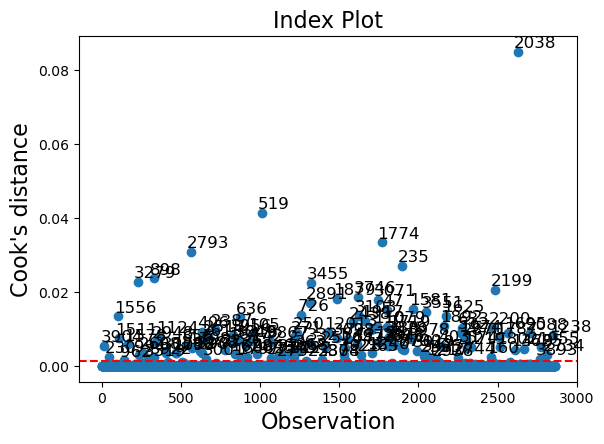

In [28]:
# Get influence measures: to initialize
influence = logistic_model_1.get_influence()

# Obtain summary df of influence measures
summ_df = influence.summary_frame()

# Filter summary df to Cook distance
diagnosis_df = summ_df.loc[:,['cooks_d']]

# Append absolute standardized residual values
diagnosis_df['std_resid'] = stats.zscore(logistic_model_1.resid_pearson)
diagnosis_df['std_resid'] = diagnosis_df.loc[:,'std_resid'].apply(lambda x: np.abs(x))

# Sort by Cook's Distance
diagnosis_df.sort_values("cooks_d", ascending=False)
diagnosis_df.head()

# Set Cook's distance threshold
cook_threshold = 4 / len(X_train)
print(f"Threshold for Cook Distance = {cook_threshold}")

import matplotlib.pyplot as plt
# Plot influence measures (Cook's distance)
fig = influence.plot_index(y_var="cooks", threshold=cook_threshold)
plt.axhline(y = cook_threshold, ls="--", color='red')
fig.tight_layout(pad=2) #those instances above the read line are influential instances.

# Find number of observations that exceed Cook's distance threshold
influentials = diagnosis_df[diagnosis_df['cooks_d'] > cook_threshold]
prop_influentials = round(100*(len(influentials) / len(X_train)),1)
print(f'Proportion of data points that are highly influential = {prop_influentials}%')


# Find number of observations which are BOTH outlier (std dev > 3) and highly influential
extreme = diagnosis_df[(diagnosis_df['cooks_d'] > cook_threshold) &
                       (diagnosis_df['std_resid'] > 3)]
prop_extreme = round(100*(len(extreme) / len(X_train)),1)

# Display top 5 most influential instances and outliers
extreme.sort_values("cooks_d", ascending=False).head()

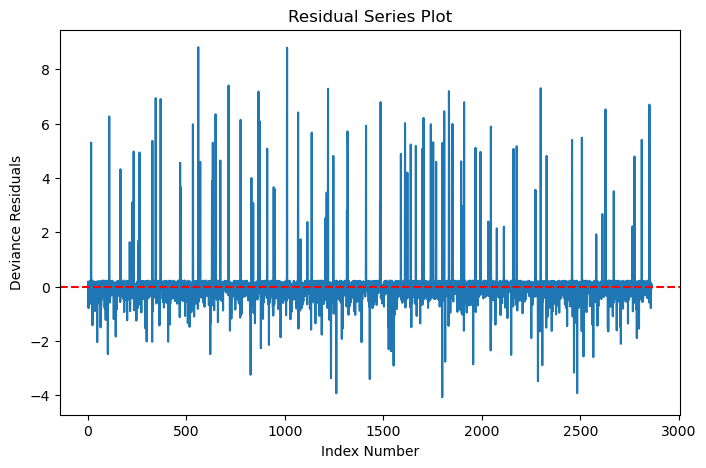

In [29]:
######################################
#to generate a residual plot
######################################

#the plot of these statistics against the index id (it is therefore also called an index plot.)
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, title="Residual Series Plot",
                     xlabel="Index Number",
                     ylabel="Deviance Residuals")
X3=list(range(0, len(X_train)))#to create a list from 0 to the sample size of X_train
# Generate residual series plot using standardized deviance residuals
ax.plot(X3,stats.zscore(logistic_model_1.resid_dev))

# Draw horizontal line at y_train=0
plt.axhline(y = 0, ls="--", color='red')
###########end of the index plot
